<a href="https://colab.research.google.com/github/TetianaMar-888/Amazon_Books_project/blob/main/04_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Logistic Regression з class_weight='balanced'

In [10]:
# 1. Завантаження
from google.colab import drive
drive.mount('/content/drive')

import pickle
with open("/content/drive/MyDrive/project_data/features_engineered.pkl", "rb") as f:
    data = pickle.load(f)

X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

# 2. Logistic Regression з class_weight='balanced'
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, accuracy_score
import time

start = time.time()
logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train, y_train)
train_time = time.time() - start

y_pred_val = logreg.predict(X_val)

print("=== Logistic Regression — Validation ===")
print(classification_report(y_val, y_pred_val, zero_division=0))
print("Macro F1:", f1_score(y_val, y_pred_val, average="macro"))
print("Accuracy:", accuracy_score(y_val, y_pred_val))
print(f"Час тренування: {train_time:.1f} сек")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Logistic Regression — Validation ===
              precision    recall  f1-score   support

    negative       0.27      0.51      0.35       483
     neutral       0.20      0.40      0.27       669
    positive       0.93      0.77      0.84      6348

    accuracy                           0.72      7500
   macro avg       0.47      0.56      0.49      7500
weighted avg       0.82      0.72      0.76      7500

Macro F1: 0.48931207885702205
Accuracy: 0.7224
Час тренування: 36.9 сек


In [11]:
import pandas as pd

new_row = {
    "model": "Logistic Regression (TF-IDF + tabular)",
    "params": "class_weight=balanced, max_iter=1000",
    "val_accuracy": accuracy_score(y_val, y_pred_val),
    "val_macro_f1": f1_score(y_val, y_pred_val, average="macro"),
    "train_time_sec": 39.0
}

results_df = pd.read_csv("/content/drive/MyDrive/project_data/experiments_table.csv")
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df.to_csv("/content/drive/MyDrive/project_data/experiments_table.csv", index=False)
print(results_df)

                                    model  \
0                Baseline (most frequent)   
1  Logistic Regression (TF-IDF + tabular)   
2  Logistic Regression (TF-IDF + tabular)   
3  Logistic Regression (TF-IDF + tabular)   
4  Logistic Regression (TF-IDF + tabular)   

                                 params  val_accuracy  val_macro_f1  \
0                                     -        0.8464      0.305604   
1  class_weight=balanced, max_iter=1000        0.7224      0.489312   
2  class_weight=balanced, max_iter=1000        0.7224      0.489312   
3  class_weight=balanced, max_iter=1000        0.7224      0.489312   
4  class_weight=balanced, max_iter=1000        0.7224      0.489312   

   train_time_sec  
0             NaN  
1            39.0  
2            39.0  
3            39.0  
4            39.0  


#XGB

In [17]:
with open("/content/drive/MyDrive/project_data/features_engineered.pkl", "rb") as f:
    data = pickle.load(f)

X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.utils import resample

X_train_sub, y_train_sub_enc = resample(
    X_train, y_train_enc, n_samples=10000, random_state=42, stratify=y_train_enc
)
sample_weights_sub = compute_sample_weight(class_weight="balanced", y=y_train_sub_enc)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train_enc)

print("Готово:", X_train.shape, X_train_sub.shape)

import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.1, 0.2],
}

xgb_base = xgb.XGBClassifier(
    objective="multi:softmax", num_class=3, eval_metric="mlogloss",
    tree_method="hist", random_state=42, n_jobs=-1
)

search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=4,
    scoring="f1_macro", cv=2, random_state=42, verbose=2, n_jobs=1
)

start = time.time()
search.fit(X_train_sub, y_train_sub_enc, sample_weight=sample_weights_sub)
search_time = time.time() - start

print("Найкращі параметри:", search.best_params_)
print("Найкращий CV macro F1:", search.best_score_)
print(f"Час тюнінгу: {search_time:.1f} сек")

# одразу зберігаємо параметри, щоб не втратити при обриві сесії
import json
with open("/content/drive/MyDrive/project_data/xgb_best_params.json", "w") as f:
    json.dump(search.best_params_, f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Готово: (34999, 10014) (10000, 10014)
Fitting 2 folds for each of 4 candidates, totalling 8 fits
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time= 1.4min
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=200; total time= 1.3min
[CV] END ...learning_rate=0.2, max_depth=3, n_estimators=200; total time= 1.3min
[CV] END ...learning_rate=0.2, max_depth=3, n_estimators=200; total time= 1.3min
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=  43.0s
[CV] END ...learning_rate=0.1, max_depth=3, n_estimators=100; total time=  40.4s
[CV] END ...learning_rate=0.2, max_depth=5, n_estimators=200; total time= 2.5min
[CV] END ...learning_rate=0.2, max_depth=5, n_estimators=200; total time= 2.4min
Найкращі параметри: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}
Найкращий CV macro F1: 0.5732524359051634
Час 

In [20]:
best_xgb = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.2,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

start = time.time()
best_xgb.fit(X_train, y_train_enc, sample_weight=sample_weights)
final_train_time = time.time() - start

print(f"Час фінального тренування: {final_train_time:.1f} сек")

Час фінального тренування: 605.5 сек


In [21]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

y_pred_val_enc = best_xgb.predict(X_val)
y_pred_val = le.inverse_transform(y_pred_val_enc)

print("=== XGBoost (tuned, full train) — Validation ===")
print(classification_report(y_val, y_pred_val, zero_division=0))
print("Macro F1:", f1_score(y_val, y_pred_val, average="macro"))
print("Accuracy:", accuracy_score(y_val, y_pred_val))

=== XGBoost (tuned, full train) — Validation ===
              precision    recall  f1-score   support

    negative       0.31      0.49      0.38       483
     neutral       0.23      0.39      0.29       669
    positive       0.92      0.82      0.87      6348

    accuracy                           0.76      7500
   macro avg       0.49      0.57      0.51      7500
weighted avg       0.82      0.76      0.79      7500

Macro F1: 0.5136572977315521
Accuracy: 0.76


In [22]:
new_row = {
    "model": "XGBoost (tuned: n_est=200, depth=5, lr=0.2)",
    "params": "n_estimators=200, max_depth=5, learning_rate=0.2, tree_method=hist",
    "val_accuracy": accuracy_score(y_val, y_pred_val),
    "val_macro_f1": f1_score(y_val, y_pred_val, average="macro"),
    "train_time_sec": final_train_time,
    "tuning_time_sec": 934.0
}

results_df = pd.read_csv("/content/drive/MyDrive/project_data/experiments_table.csv")
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df.to_csv("/content/drive/MyDrive/project_data/experiments_table.csv", index=False)
print(results_df)

                                         model  \
0                     Baseline (most frequent)   
1       Logistic Regression (TF-IDF + tabular)   
2       Logistic Regression (TF-IDF + tabular)   
3       Logistic Regression (TF-IDF + tabular)   
4       Logistic Regression (TF-IDF + tabular)   
5                              XGBoost (tuned)   
6  XGBoost (tuned: n_est=200, depth=5, lr=0.2)   

                                              params  val_accuracy  \
0                                                  -        0.8464   
1               class_weight=balanced, max_iter=1000        0.7224   
2               class_weight=balanced, max_iter=1000        0.7224   
3               class_weight=balanced, max_iter=1000        0.7224   
4               class_weight=balanced, max_iter=1000        0.7224   
5  {'n_estimators': 200, 'max_depth': 5, 'learnin...        0.7720   
6  n_estimators=200, max_depth=5, learning_rate=0...        0.7600   

   val_macro_f1  train_time_sec  tunin

In [23]:
with open("/content/drive/MyDrive/project_data/xgb_model_tuned.pkl", "wb") as f:
    pickle.dump({"model": best_xgb, "label_encoder": le}, f)

print("Модель збережена!")

Модель збережена!


In [24]:
import pandas as pd

results_df = pd.read_csv("/content/drive/MyDrive/project_data/experiments_table.csv")

# Прибираємо повні дублікати (однакова модель+параметри+метрики)
results_df = results_df.drop_duplicates(subset=["model", "val_macro_f1"], keep="last")
results_df = results_df.reset_index(drop=True)

print(results_df)
results_df.to_csv("/content/drive/MyDrive/project_data/experiments_table.csv", index=False)

                                         model  \
0                     Baseline (most frequent)   
1       Logistic Regression (TF-IDF + tabular)   
2                              XGBoost (tuned)   
3  XGBoost (tuned: n_est=200, depth=5, lr=0.2)   

                                              params  val_accuracy  \
0                                                  -        0.8464   
1               class_weight=balanced, max_iter=1000        0.7224   
2  {'n_estimators': 200, 'max_depth': 5, 'learnin...        0.7720   
3  n_estimators=200, max_depth=5, learning_rate=0...        0.7600   

   val_macro_f1  train_time_sec  tuning_time_sec  
0      0.305604             NaN              NaN  
1      0.489312       39.000000              NaN  
2      0.524442      934.034993              NaN  
3      0.513657      605.479698            934.0  


In [25]:
# Залишаємо тільки найкращі/унікальні записи по кожній моделі
final_table = results_df.loc[results_df.groupby("model")["val_macro_f1"].idxmax()]
print(final_table)
final_table.to_csv("/content/drive/MyDrive/project_data/experiments_table_final.csv", index=False)

                                         model  \
0                     Baseline (most frequent)   
1       Logistic Regression (TF-IDF + tabular)   
2                              XGBoost (tuned)   
3  XGBoost (tuned: n_est=200, depth=5, lr=0.2)   

                                              params  val_accuracy  \
0                                                  -        0.8464   
1               class_weight=balanced, max_iter=1000        0.7224   
2  {'n_estimators': 200, 'max_depth': 5, 'learnin...        0.7720   
3  n_estimators=200, max_depth=5, learning_rate=0...        0.7600   

   val_macro_f1  train_time_sec  tuning_time_sec  
0      0.305604             NaN              NaN  
1      0.489312       39.000000              NaN  
2      0.524442      934.034993              NaN  
3      0.513657      605.479698            934.0  


#DistilBert model

In [3]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "немає GPU")

True Tesla T4


In [4]:
!pip install transformers datasets accelerate --quiet

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")

from sklearn.model_selection import train_test_split

X = df["full_text"]
y = df["sentiment"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)

Mounted at /content/drive
(34999,) (7500,) (7500,)


Fine-tuning на всіх 35 000 текстах займе довго навіть на GPU. Залишаємо підвибірку 8 000-10 000 для train (stratified).

In [6]:
from sklearn.utils import resample

X_train_sub, y_train_sub = resample(
    X_train, y_train, n_samples=10000, random_state=42, stratify=y_train
)

print(y_train_sub.value_counts())

sentiment
positive    8463
neutral      893
negative     644
Name: count, dtype: int64


In [7]:
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
label_map = {"negative": 0, "neutral": 1, "positive": 2}

class ReviewsDataset(TorchDataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.encodings = tokenizer(
            list(texts), truncation=True, padding="max_length",
            max_length=max_length, return_tensors="pt"
        )
        self.labels = [label_map[l] for l in labels]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

train_ds = ReviewsDataset(X_train_sub, y_train_sub, tokenizer)
val_ds = ReviewsDataset(X_val, y_val, tokenizer)

print(len(train_ds), len(val_ds))

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

10000 7500


In [8]:
import torch.nn as nn
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments

class_weights = torch.tensor([
    1.0 / (y_train_sub == "negative").mean(),
    1.0 / (y_train_sub == "neutral").mean(),
    1.0 / (y_train_sub == "positive").mean(),
], dtype=torch.float)
class_weights = class_weights / class_weights.sum() * 3  # нормалізація

print("Ваги класів:", class_weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

Ваги класів: tensor([1.6692, 1.2038, 0.1270])


In [9]:
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)

from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds)
    }

training_args = TrainingArguments(
    output_dir="/content/bert_output",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

import time
start = time.time()
trainer.train()
train_time = time.time() - start
print(f"Час тренування: {train_time:.1f} сек")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.614127,0.729927,0.656639,0.854533
2,0.394828,0.926803,0.697089,0.880533
3,0.172444,1.350666,0.696097,0.892800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Час тренування: 813.3 сек


In [10]:
from sklearn.metrics import classification_report

preds_output = trainer.predict(val_ds)
y_pred_enc = np.argmax(preds_output.predictions, axis=-1)
y_pred = [list(label_map.keys())[list(label_map.values()).index(p)] for p in y_pred_enc]

print("=== DistilBERT — Validation ===")
print(classification_report(y_val, y_pred, zero_division=0))
print("Macro F1:", f1_score(y_val, y_pred, average="macro"))
print("Accuracy:", accuracy_score(y_val, y_pred))

# Збереження моделі та результатів
trainer.save_model("/content/drive/MyDrive/project_data/distilbert_model")
tokenizer.save_pretrained("/content/drive/MyDrive/project_data/distilbert_model")

import pandas as pd
new_row = {
    "model": "DistilBERT (fine-tuned, 8k subsample)",
    "params": "epochs=3, batch_size=16, max_length=256",
    "val_accuracy": accuracy_score(y_val, y_pred),
    "val_macro_f1": f1_score(y_val, y_pred, average="macro"),
    "train_time_sec": train_time
}

results_df = pd.read_csv("/content/drive/MyDrive/project_data/experiments_table.csv")
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df.to_csv("/content/drive/MyDrive/project_data/experiments_table.csv", index=False)
print(results_df)

=== DistilBERT — Validation ===
              precision    recall  f1-score   support

    negative       0.64      0.66      0.65       483
     neutral       0.44      0.57      0.50       669
    positive       0.96      0.93      0.95      6348

    accuracy                           0.88      7500
   macro avg       0.68      0.72      0.70      7500
weighted avg       0.90      0.88      0.89      7500

Macro F1: 0.6970888255394351
Accuracy: 0.8805333333333333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

                                         model  \
0                     Baseline (most frequent)   
1       Logistic Regression (TF-IDF + tabular)   
2                              XGBoost (tuned)   
3  XGBoost (tuned: n_est=200, depth=5, lr=0.2)   
4        DistilBERT (fine-tuned, 8k subsample)   

                                              params  val_accuracy  \
0                                                  -      0.846400   
1               class_weight=balanced, max_iter=1000      0.722400   
2  {'n_estimators': 200, 'max_depth': 5, 'learnin...      0.772000   
3  n_estimators=200, max_depth=5, learning_rate=0...      0.760000   
4            epochs=3, batch_size=16, max_length=256      0.880533   

   val_macro_f1  train_time_sec  tuning_time_sec  
0      0.305604             NaN              NaN  
1      0.489312       39.000000              NaN  
2      0.524442      934.034993              NaN  
3      0.513657      605.479698            934.0  
4      0.697089      81

# Claude API

In [11]:
!pip install anthropic --quiet

import anthropic
from google.colab import userdata

api_key = userdata.get('ANTHROPIC_API_KEY')
client = anthropic.Anthropic(api_key=api_key)

print("Ключ отримано, довжина:", len(api_key))

Ключ отримано, довжина: 108


In [4]:
from sklearn.utils import resample

X_val_sample, y_val_sample = resample(
    X_val, y_val, n_samples=400, random_state=42, stratify=y_val
)

print(y_val_sample.value_counts())

sentiment
positive    338
neutral      36
negative     26
Name: count, dtype: int64


In [5]:
import time
import re

def classify_sentiment_llm(text, client, model="claude-sonnet-4-6", max_retries=3):
    prompt = f"""Classify the sentiment of this book review as exactly one word: negative, neutral, or positive.

Review: "{text[:1000]}"

Respond with only one word: negative, neutral, or positive."""

    for attempt in range(max_retries):
        try:
            response = client.messages.create(
                model=model,
                max_tokens=10,
                messages=[{"role": "user", "content": prompt}]
            )
            answer = response.content[0].text.strip().lower()
            answer = re.sub(r"[^a-z]", "", answer)  # прибрати зайві символи/пунктуацію

            if answer in ["negative", "neutral", "positive"]:
                return answer
            else:
                return "positive"  # fallback на найчастіший клас, якщо відповідь незрозуміла
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # експоненційна затримка при помилці
            else:
                print(f"Помилка після {max_retries} спроб: {e}")
                return "positive"

In [12]:
from tqdm import tqdm

y_pred_llm = []
for text in tqdm(X_val_sample, desc="Класифікація через Claude API"):
    pred = classify_sentiment_llm(text, client)
    y_pred_llm.append(pred)
    time.sleep(0.1)  # невелика затримка, щоб не перевищити rate limits

print("Завершено!")

Класифікація через Claude API: 100%|██████████| 400/400 [11:35<00:00,  1.74s/it]

Завершено!


In [13]:
from sklearn.metrics import classification_report, f1_score, accuracy_score

print("=== Claude API (zero-shot) — Validation subsample (n=400) ===")
print(classification_report(y_val_sample, y_pred_llm, zero_division=0))
print("Macro F1:", f1_score(y_val_sample, y_pred_llm, average="macro"))
print("Accuracy:", accuracy_score(y_val_sample, y_pred_llm))

=== Claude API (zero-shot) — Validation subsample (n=400) ===
              precision    recall  f1-score   support

    negative       0.66      0.88      0.75        26
     neutral       0.44      0.47      0.45        36
    positive       0.97      0.93      0.95       338

    accuracy                           0.89       400
   macro avg       0.69      0.76      0.72       400
weighted avg       0.90      0.89      0.89       400

Macro F1: 0.7187422915706542
Accuracy: 0.8875


In [14]:
import pandas as pd

new_row = {
    "model": "Claude API (zero-shot, n=400 subsample)",
    "params": "model=claude-sonnet-4-6, zero-shot prompt",
    "val_accuracy": accuracy_score(y_val_sample, y_pred_llm),
    "val_macro_f1": f1_score(y_val_sample, y_pred_llm, average="macro"),
    "train_time_sec": 0  # немає тренування - zero-shot
}

results_df = pd.read_csv("/content/drive/MyDrive/project_data/experiments_table.csv")
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)
results_df.to_csv("/content/drive/MyDrive/project_data/experiments_table.csv", index=False)
print(results_df)

# Зберігаю самі передбачення для подальшого аналізу помилок
import pickle
with open("/content/drive/MyDrive/project_data/llm_predictions.pkl", "wb") as f:
    pickle.dump({"X_val_sample": X_val_sample, "y_val_sample": y_val_sample, "y_pred_llm": y_pred_llm}, f)

                                         model  \
0                     Baseline (most frequent)   
1       Logistic Regression (TF-IDF + tabular)   
2                              XGBoost (tuned)   
3  XGBoost (tuned: n_est=200, depth=5, lr=0.2)   
4        DistilBERT (fine-tuned, 8k subsample)   
5      Claude API (zero-shot, n=400 subsample)   

                                              params  val_accuracy  \
0                                                  -      0.846400   
1               class_weight=balanced, max_iter=1000      0.722400   
2  {'n_estimators': 200, 'max_depth': 5, 'learnin...      0.772000   
3  n_estimators=200, max_depth=5, learning_rate=0...      0.760000   
4            epochs=3, batch_size=16, max_length=256      0.880533   
5          model=claude-sonnet-4-6, zero-shot prompt      0.887500   

   val_macro_f1  train_time_sec  tuning_time_sec  
0      0.305604             NaN              NaN  
1      0.489312       39.000000              NaN  
2    

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pickle
import pandas as pd
import numpy as np

# 1. Завантаження готових фічей (спліт + TF-IDF + табличні)
with open("/content/drive/MyDrive/project_data/features_engineered.pkl", "rb") as f:
    data = pickle.load(f)

X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]
tfidf = data["tfidf"]

print("Фічі відновлено:", X_train.shape, X_val.shape)

# 2. Logistic Regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_val_logreg = logreg.predict(X_val)
print("Logistic Regression готовий")

# 3. XGBoost - завантажуємо tuned-версію (робоча)
import pickle

with open("/content/drive/MyDrive/project_data/xgb_model_tuned.pkl", "rb") as f:
    xgb_data = pickle.load(f)

xgb_model = xgb_data["model"]
le = xgb_data["label_encoder"]

y_pred_val_xgb_enc = xgb_model.predict(X_val)
y_pred_val_xgb = le.inverse_transform(y_pred_val_xgb_enc)
print("XGBoost (tuned) відновлено")

# 4. DistilBERT - папка "distilbert_model"
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from torch.utils.data import Dataset as TorchDataset, DataLoader

bert_model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/project_data/distilbert_model"
)
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "/content/drive/MyDrive/project_data/distilbert_model"
)
device = "cuda" if torch.cuda.is_available() else "cpu"
bert_model.to(device)
bert_model.eval()

label_map = {"negative": 0, "neutral": 1, "positive": 2}
inv_label_map = {v: k for k, v in label_map.items()}

# Текстовий X_val (full_text) для BERT
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")
X_text = df["full_text"]
y_text = df["sentiment"]
X_train_text, X_temp_text, y_train_text, y_temp_text = train_test_split(
    X_text, y_text, test_size=0.3, stratify=y_text, random_state=42
)
X_val_text, X_test_text, y_val_text, y_test_text = train_test_split(
    X_temp_text, y_temp_text, test_size=0.5, stratify=y_temp_text, random_state=42
)

class ReviewsDataset(TorchDataset):
    def __init__(self, texts, tokenizer, max_length=256):
        self.encodings = tokenizer(list(texts), truncation=True, padding="max_length",
                                     max_length=max_length, return_tensors="pt")
    def __len__(self): return len(self.encodings["input_ids"])
    def __getitem__(self, idx):
        return {key: val[idx] for key, val in self.encodings.items()}

val_ds = ReviewsDataset(X_val_text, tokenizer)
loader = DataLoader(val_ds, batch_size=32)

all_preds = []
with torch.no_grad():
    for batch in loader:
        inputs = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(**inputs)
        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend(preds)

y_pred = [inv_label_map[p] for p in all_preds]
print("DistilBERT відновлено")

# 5. Claude API - збережені передбачення
with open("/content/drive/MyDrive/project_data/llm_predictions.pkl", "rb") as f:
    llm_data = pickle.load(f)

X_val_sample = llm_data["X_val_sample"]
y_val_sample = llm_data["y_val_sample"]
y_pred_llm = llm_data["y_pred_llm"]
print("Claude API передбачення відновлено")

print("\nВСЕ ГОТОВО! Можна будувати confusion matrices.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Фічі відновлено: (34999, 10014) (7500, 10014)
Logistic Regression готовий
XGBoost (tuned) відновлено


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT відновлено
Claude API передбачення відновлено

ВСЕ ГОТОВО! Можна будувати confusion matrices.


In [3]:
import os

files = os.listdir("/content/drive/MyDrive/project_data")
for f in files:
    path = f"/content/drive/MyDrive/project_data/{f}"
    size = os.path.getsize(path)
    print(f"{f}: {size/1024/1024:.2f} MB")

reviews_books_sample.parquet: 24.77 MB
meta_books_sample.parquet: 158.78 MB
merged_books.parquet: 203.52 MB
sentiment_distribution.png: 0.04 MB
text_length_by_sentiment.png: 0.04 MB
text_length_by_sentiment_no_outliers.png: 0.04 MB
numeric_distributions.png: 0.09 MB
correlation_matrix.png: 0.08 MB
verified_purchase_sentiment.png: 0.03 MB
books_cleaned.parquet: 515.33 MB
top_words_by_sentiment.png: 0.07 MB
01_eda.ipynb: 0.52 MB
train_val_test_split.pkl: 233.41 MB
features_engineered.pkl: 130.49 MB
xgb_best_params.json: 0.00 MB
xgb_model.pkl: 0.00 MB
xgb_model_tuned.pkl: 1.05 MB
experiments_table_final.csv: 0.00 MB
distilbert_model: 0.00 MB
llm_predictions.pkl: 1.61 MB
experiments_table.csv: 0.00 MB


#Confusion Matrix для порівняння всіх моделей

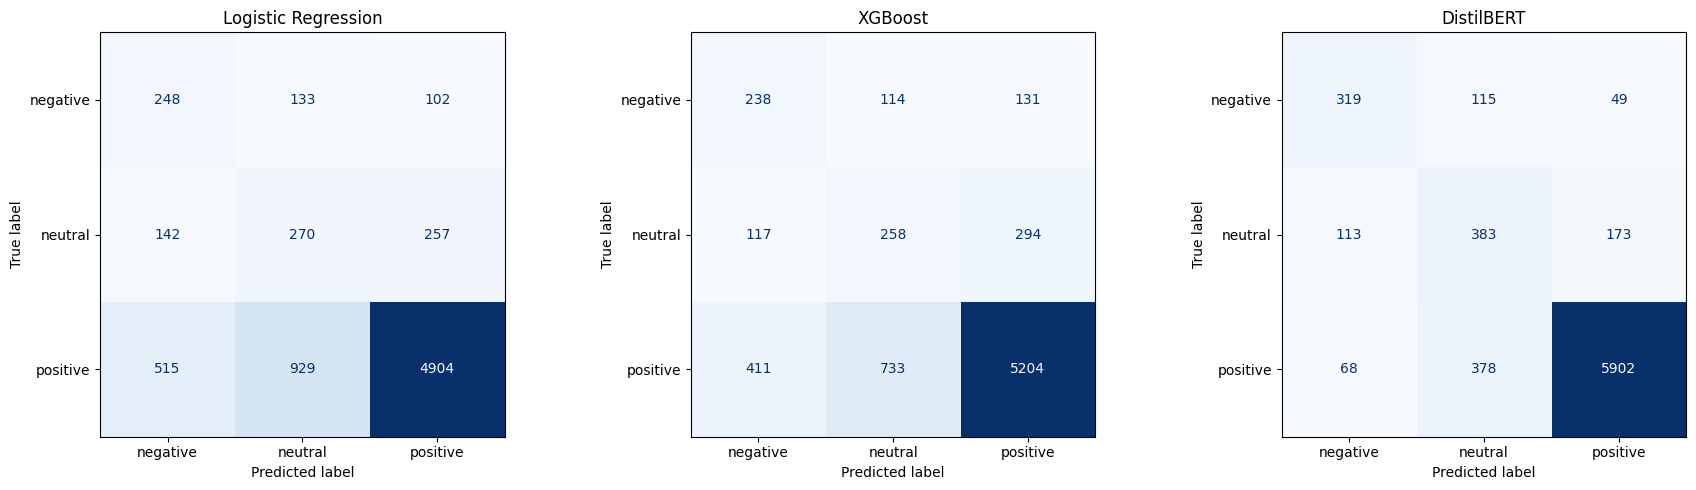

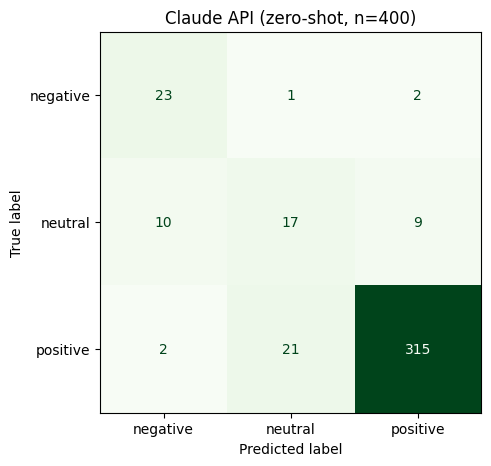

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels_order = ["negative", "neutral", "positive"]

models_preds = {
    "Logistic Regression": (y_val, y_pred_val_logreg),
    "XGBoost": (y_val, y_pred_val_xgb),
    "DistilBERT": (y_val, y_pred),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (y_true, y_p)) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_true, y_p, labels=labels_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/confusion_matrices_classical.png", dpi=150)
plt.show()

# Окремо - Claude API (на підвибірці 400)
fig, ax = plt.subplots(figsize=(5, 5))
cm_llm = confusion_matrix(y_val_sample, y_pred_llm, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_llm, display_labels=labels_order)
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Claude API (zero-shot, n=400)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/confusion_matrix_llm.png", dpi=150)
plt.show()

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Відновлюємо df і той самий спліт, щоб отримати main_category для train
df = pd.read_parquet("/content/drive/MyDrive/project_data/books_cleaned.parquet")

X_full = df[["full_text", "price_clean", "verified_purchase", "helpful_vote",
             "main_category", "average_rating", "rating_number"]]
y_full = df["sentiment"]

X_train_orig, X_temp_orig, y_train_orig, y_temp_orig = train_test_split(
    X_full, y_full, test_size=0.3, stratify=y_full, random_state=42
)

# Перевідновлюємо назви one-hot колонок
ohe_check = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_check.fit(X_train_orig[["main_category"]])
cat_cols = ohe_check.get_feature_names_out(["main_category"])

tabular_feature_names = ["price_clean", "helpful_vote", "average_rating", "rating_number", "verified_purchase"] + list(cat_cols)

# TF-IDF назви
tfidf_feature_names = tfidf.get_feature_names_out()

all_feature_names = np.concatenate([tfidf_feature_names, tabular_feature_names])
print("Загальна кількість ознак:", len(all_feature_names), "vs модель очікує:", len(xgb_model.feature_importances_))

Загальна кількість ознак: 10014 vs модель очікує: 10014


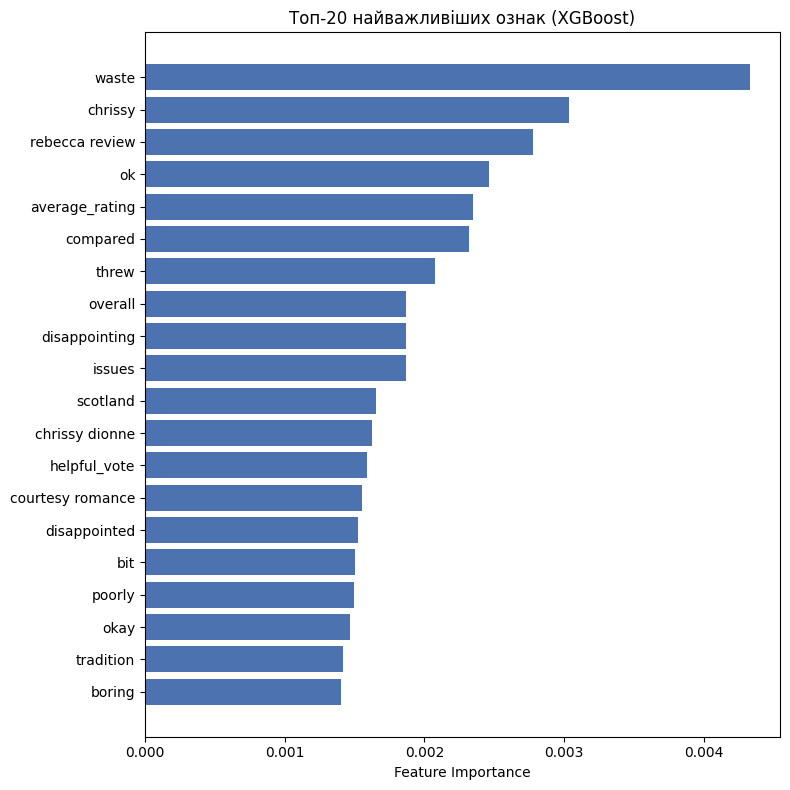

In [13]:
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(range(top_n), importances[top_idx][::-1], color="#4C72B0")
ax.set_yticks(range(top_n))
ax.set_yticklabels(all_feature_names[top_idx][::-1])
ax.set_xlabel("Feature Importance")
ax.set_title("Топ-20 найважливіших ознак (XGBoost)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/project_data/feature_importance_xgb.png", dpi=150)
plt.show()

In [14]:
X_val_reset = pd.Series(X_val_text).reset_index(drop=True)
y_val_reset = pd.Series(y_val_text).reset_index(drop=True)

errors_df = pd.DataFrame({
    "text": X_val_reset,
    "true_label": y_val_reset,
    "predicted": y_pred
})

critical_errors = errors_df[
    ((errors_df["true_label"] == "negative") & (errors_df["predicted"] == "positive")) |
    ((errors_df["true_label"] == "positive") & (errors_df["predicted"] == "negative"))
]

print(f"Критичні помилки DistilBERT: {len(critical_errors)}")
for idx, row in critical_errors.head(5).iterrows():
    print(f"\n--- Правда: {row['true_label']} | Передбачено: {row['predicted']} ---")
    print(row["text"][:300])

Критичні помилки DistilBERT: 117

--- Правда: positive | Передбачено: negative ---
Omg finally I understand. I hated puzzle caches...just because they confused me or I thought they made no sense. Now I'm attempting them with better understanding and success.. 

--- Правда: negative | Передбачено: positive ---
I'm through. There seems to come a time when the liberal in personalities, even authors comes out. They can't seem to not push their political views on us. I think because because of their popularity they must think they've become "God like". Well, I'm through reading Michael Connelly . I hope other

--- Правда: negative | Передбачено: positive ---
Is it the fifties again?. If you enjoy pretending to be back in the fifties when men were men and women were women, you'll think this book makes sense.. About the Author Bruce Weinstein has been designing knitwear and teaching knitting for 10 years and has written 15 cookbooks with his partner, Mark

--- Правда: negative | Передбачено: 